# **Race/Ethnic Classification by Face using MobileNetV2**

## **Ekstrak Label/Class**

In [6]:
import pandas as pd
import os

# 1. Load file CSV
train_df = pd.read_csv('./Dataset/fairface_label_train.csv')
val_df = pd.read_csv('./Dataset/fairface_label_val.csv')

# 2. Filter hanya kolom yang dibutuhkan (file path dan race)
# Kita pastikan kolom 'file' sesuai dengan lokasi fisik gambar di folder
train_data = train_df[['file', 'race']]
val_data = val_df[['file', 'race']]

# 3. Cek distribusi label (Penting untuk melihat apakah dataset seimbang)
print("Distribusi Ras di Training:")
print(train_data['race'].value_counts())

# 4. Contoh akses data
# Jika folder 'train' berada di dalam directory yang sama dengan script:
# train_data['full_path'] = 'data_dir/' + train_data['file']

print("\nData siap diproses!")
print(train_data.head())

Distribusi Ras di Training:
race
White              16527
Latino_Hispanic    13367
Indian             12319
East Asian         12287
Black              12233
Southeast Asian    10795
Middle Eastern      9216
Name: count, dtype: int64

Data siap diproses!
          file        race
0  train/1.jpg  East Asian
1  train/2.jpg      Indian
2  train/3.jpg       Black
3  train/4.jpg      Indian
4  train/5.jpg      Indian


## **Ekstraksi Label & Setup Data Generator**

In [7]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Load file CSV sesuai nama terbaru
train_df = pd.read_csv('./Dataset/fairface_label_train.csv')
val_df = pd.read_csv('./Dataset/fairface_label_val.csv')

# 2. Setup Data Generator (Optimasi untuk RAM 5,7GB)
# Kita gunakan rescale 1/255 agar nilai piksel ada di rentang 0-1
datagen = ImageDataGenerator(rescale=1./255)

# Parameter Penyelamat Memory
IMG_SIZE = (128, 128) 
BATCH_SIZE = 16 # Jika nanti masih terasa berat/crash, turunkan ke 8

# Generator Latih
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='Dataset',    # <--- TAMBAHKAN INI: Folder induk dari 'train' dan 'val'
    x_col='file',           # Berisi 'train/1.jpg', dst
    y_col='race',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Generator Validasi
val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory='Dataset',    # <--- TAMBAHKAN INI
    x_col='file',           # Berisi 'val/1.jpg', dst
    y_col='race',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 86744 validated image filenames belonging to 7 classes.
Found 10954 validated image filenames belonging to 7 classes.


## **Arsitektur Model MobileNetV2 (Transfer Learning)**

In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load MobileNetV2 tanpa layer output asli
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(128, 128, 3)
)

# FREEZE: Jangan latih ulang base model agar hemat komputasi
base_model.trainable = False 

# Tambahkan layer baru khusus untuk klasifikasi Ras
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x) # Memberikan sedikit ruang agar model tidak kaku

# Output layer menyesuaikan jumlah ras di dataset
num_classes = len(train_generator.class_indices)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Kompilasi
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # LR lebih kecil agar stabil
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## **Training Model**

Epoch 1/20
5421/5421 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3483 - loss: 1.6651
Epoch 1: val_accuracy improved from None to 0.37546, saving model to output/best_model_race_classification.keras

Epoch 1: finished saving model to output/best_model_race_classification.keras
5421/5421 ━━━━━━━━━━━━━━━━━━━━ 1724s 318ms/step - accuracy: 0.3485 - loss: 1.6625 - val_accuracy: 0.3755 - val_loss: 1.6049 - learning_rate: 0.0010
Epoch 2/20
   1/5421 ━━━━━━━━━━━━━━━━━━━━ 35:16 390ms/step - accuracy: 0.3750 - loss: 1.5663

/home/qiddis/Documents/SEMESTER 6/ComputerVision/Project_UAS/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.37546
5421/5421 ━━━━━━━━━━━━━━━━━━━━ 192s 35ms/step - accuracy: 0.3750 - loss: 1.5663 - val_accuracy: 0.3750 - val_loss: 1.6062 - learning_rate: 0.0010
Epoch 3/20
5421/5421 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.3541 - loss: 1.6471
Epoch 3: val_accuracy improved from 0.37546 to 0.37856, saving model to output/best_model_race_classification.keras

Epoch 3: finished saving model to output/best_model_race_classification.keras
5421/5421 ━━━━━━━━━━━━━━━━━━━━ 1689s 312ms/step - accuracy: 0.3553 - loss: 1.6430 - val_accuracy: 0.3786 - val_loss: 1.5829 - learning_rate: 0.0010
Epoch 4/20
   1/5421 ━━━━━━━━━━━━━━━━━━━━ 24:48 275ms/step - accuracy: 0.4375 - loss: 1.7171
Epoch 4: val_accuracy improved from 0.37856 to 0.37948, saving model to output/best_model_race_classification.keras

Epoch 4: finished saving model to output/best_model_race_classification.keras
5421/5421 ━━━━━━━━━━━━━━━━━━━━ 199s 37ms/step - accuracy: 0.4375 - loss: 1.7171 -

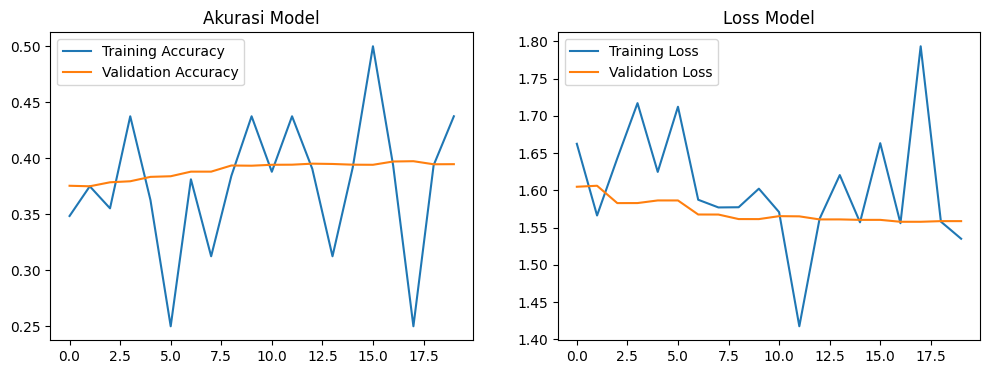

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

# 1. KONFIGURASI CALLBACKS
# EarlyStopping: Menghentikan training jika val_loss tidak turun selama 5 epoch berturut-turut.
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: Menurunkan learning rate jika akurasi mulai mentok.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6,
    verbose=1
)

# ModelCheckpoint: Otomatis menyimpan model terbaik yang berhasil dilatih.
checkpoint = ModelCheckpoint(
    'output/best_model_race_classification.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# 2. PROSES TRAINING
# Kita mulai dengan 20 epoch. EarlyStopping kemungkinan akan menghentikannya lebih cepat.
EPOCHS = 20

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# 3. VISUALISASI HASIL
# Membuat grafik Akurasi dan Loss untuk melihat performa model
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Akurasi Model')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss Model')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ambil label asli dan prediksi dari validation generator
val_generator.reset() # Reset agar urutan tidak berantakan
Y_pred = model.predict(val_generator, steps=val_generator.samples // BATCH_SIZE + 1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# 2. Ambil nama-nama kelas (Ras)
class_labels = list(val_generator.class_indices.keys())

# 3. Hitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Visualisasi dengan Seaborn Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Klasifikasi Ras')
plt.ylabel('Label Asli (True)')
plt.xlabel('Prediksi Model')
plt.show()

# 5. Print Metrik Evaluasi Lengkap (Precision, Recall, F1-Score)
print("\n--- Laporan Klasifikasi (Metrik Evaluasi) ---")
print(classification_report(y_true, y_pred, target_names=class_labels))